In [3]:
from Cities import City, Data, DataLoader
from Generation import *
from GeneticAlgorithm import *
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# Práctica 2 (Algoritmos Genéticos)

## Introducción
En esta práctica se ha llevado a cabo un algoritmo genético que es capaz de resolver el problema del viajero (también conocido como TSP). Para ello, se ha seguido un desarrollo basado en la *programación orientada a objetos* para poder modular y encapsular conceptos y funcionalidades. Están todos los archivos necesarios para ejecutar este notebook en la misma carpeta y repositorio de GitHub. Aquí se presenta el estudio de los parámetros que influyen en hayar la solución óptima dados los datos iniciales proporcionados.

## Primera versión
En esta versión, el algoritmo de cruce es muy similar al implementado en clase. La única cuestión que varía aquí es la cantidad de padres que se pueden escoger, puesto que también me parecía relevante como variable a estudiar de forma extraordinaria. Para ello, se ha implementado un algoritmo que coge un individuo (madre) y un padre. El cruce se lleva a cabo copiando exactamente un segmento de los genes de la madre y se completan (en orden) con los genes del padre. Cabe aclarar, que los genes son las ciudades en un ciclo cerrado, es decir, que el primer gen y el último van a ser el mismo. El objeto de esta propuesta de genoma es para poder comparar de manera más fácil con la solución que proporciona el equipo docente.

Aquí se puede ver cómo convergen los diferentes individuos con diferentes tasas de mutación y de número de padres. En este caso, se cometió un error en el que había mucha endogamia debido a que los propios padres se añadían a la nueva generación. Pero después de experimentar un poco, no variaba significativamente el resultado, por ello se deja así para menor tiempo de procesamiento.

Empezando experimento con 1500 generaciones de 500 individuos
Mejor distancia es 33523.71
Ejecutando test 0 de 8. 
 Parámetros:
Mutation rate: 0.03
Parent number: 150
Generation 0
Generation 100
Generation 200
Generation 300
Generation 400
Generation 500
Generation 600
Generation 700
Generation 800
Generation 900
Mejor distancia: 42743.14907453426
Ejecutando test 1 de 8. 
 Parámetros:
Mutation rate: 0.03
Parent number: 50
Generation 0
Generation 100
Generation 200
Generation 300
Generation 400
Generation 500
Generation 600
Generation 700
Generation 800
Generation 900
Mejor distancia: 44736.5828518714
Ejecutando test 2 de 8. 
 Parámetros:
Mutation rate: 0.05
Parent number: 150
Generation 0
Generation 100
Generation 200
Generation 300
Generation 400
Generation 500
Generation 600
Generation 700
Generation 800
Generation 900
Mejor distancia: 38380.23117966669
Ejecutando test 3 de 8. 
 Parámetros:
Mutation rate: 0.05
Parent number: 50
Generation 0
Generation 100
Generation 200
Generation 30

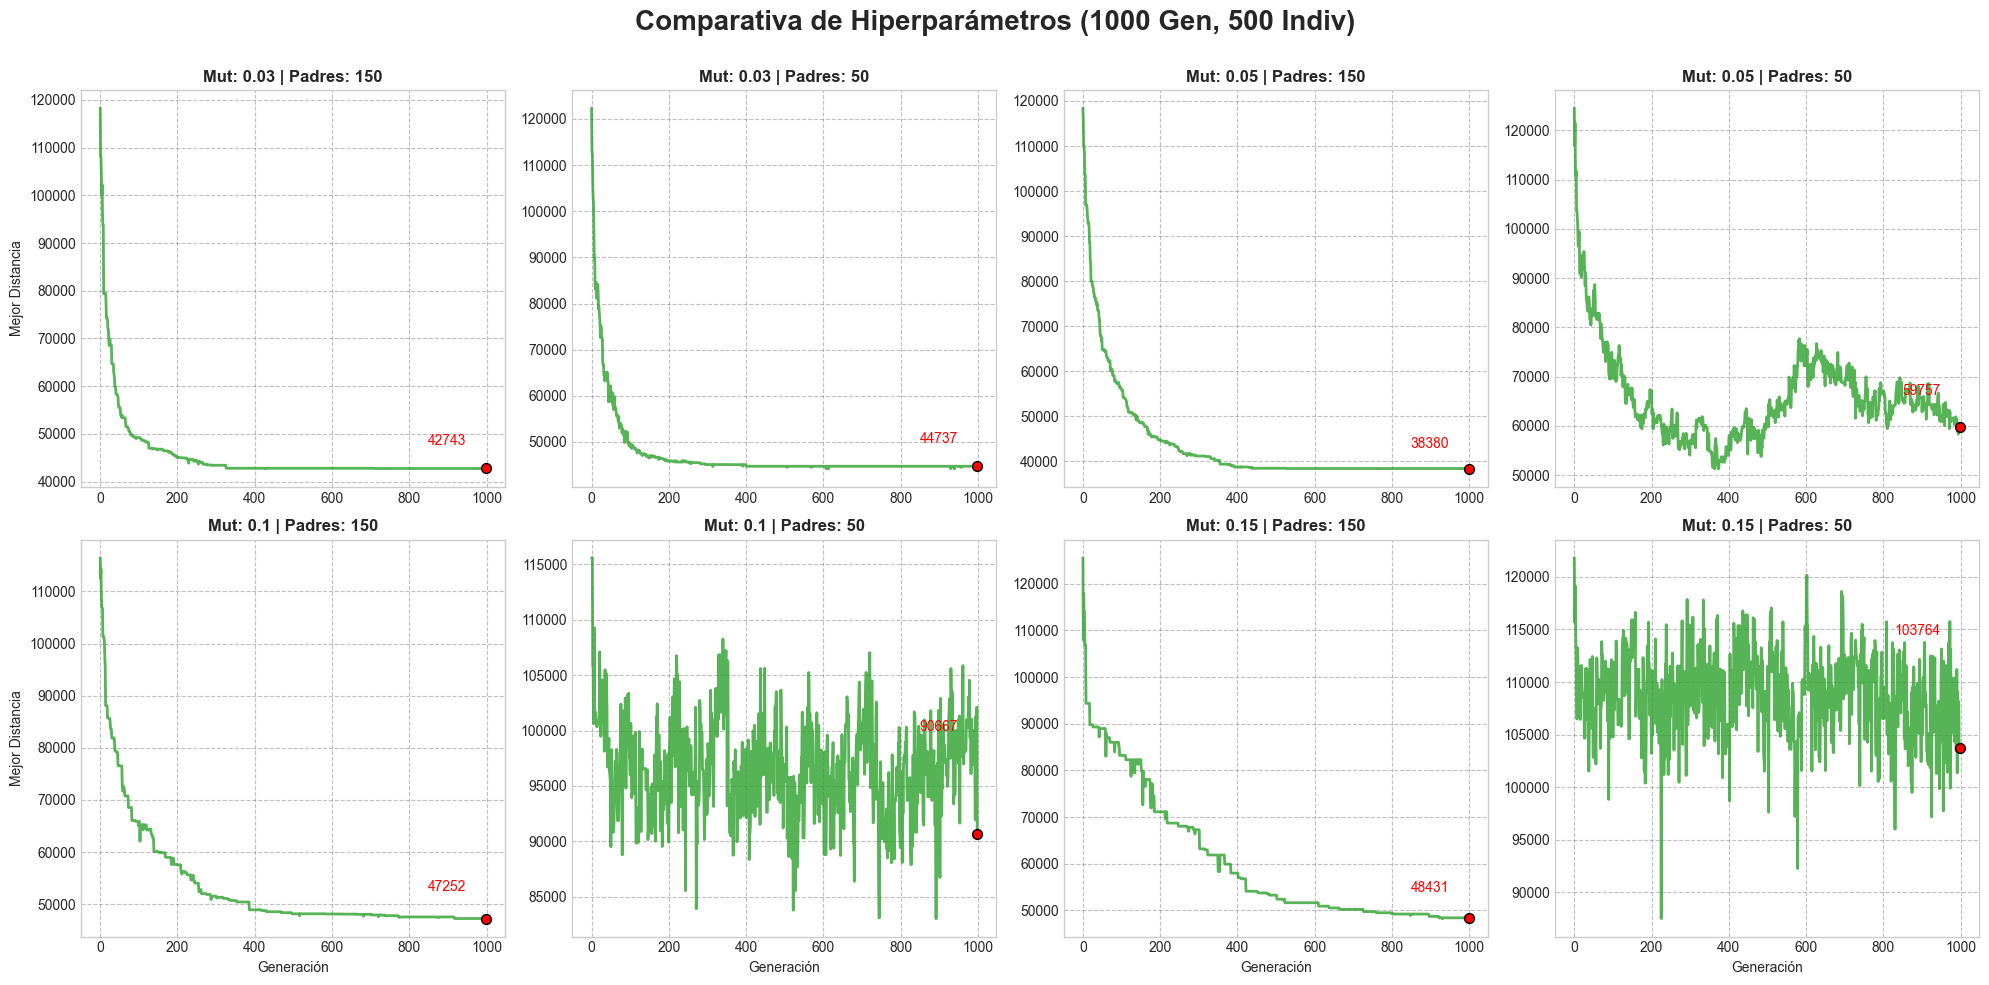

In [4]:
print("Empezando experimento con 1500 generaciones de 500 individuos")
generations, population_num = 1000, 500
tests = [(0.03, 150), (0.03,50), (0.05, 150), (0.05, 50), (0.1, 150), (0.1,50), (0.15,150), (0.15,50)]
data = DataLoader.load_data("coordinates.txt", "solution.txt")
print(f"Mejor distancia es {data.get_solution_distance():.2f}")
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), dpi=100)
fig.suptitle('Comparativa de Hiperparámetros (1000 Gen, 500 Indiv)', fontsize=20, fontweight='bold')
axes = axes.flatten()
for i, test in enumerate(tests):
    mutation_rate, parent_num = test
    print(f"Ejecutando test {i} de 8. \n Parámetros:\nMutation rate: {mutation_rate}\nParent number: {parent_num}")
    best, history = genetic_algorithm(data, population_num, generations, mutation_rate, parent_num)
    print(f'Mejor distancia: {best.distance}')
    # Seleccionamos el subplot específico para este test
    ax = axes[i]

    # 3. PINTAR EN EL SUBPLOT
    ax.plot(history, color='#2ca02c', linewidth=2, alpha=0.8)

    ultimo_gen = len(history) - 1
    ultima_dist = history[-1]
    ax.scatter(ultimo_gen, ultima_dist, color='red', s=50, edgecolor='black', zorder=5)

    ax.set_title(f'Mut: {mutation_rate} | Padres: {parent_num}', fontsize=12, fontweight='bold')

    if i % 4 == 0:
        ax.set_ylabel('Mejor Distancia', fontsize=10)

    if i >= 4:
        ax.set_xlabel('Generación', fontsize=10)

    ax.grid(True, linestyle='--', alpha=0.5, color='gray')

    ax.annotate(f'{ultima_dist:.0f}',
                xy=(ultimo_gen, ultima_dist),
                xytext=(ultimo_gen - 50, ultima_dist + (ultima_dist * 0.1)),
                ha='right', va='bottom', fontsize=10, color='red')
plt.tight_layout()
fig.subplots_adjust(top=0.90)
plt.show()

Como se observa en la gráfica superior, el algoritmo presenta tres fases claras. Una fase inicial de "caída en picado" donde el cruce ensambla rápidamente los tramos obvios, bajando la distancia drásticamente en las primeras 100 generaciones. Posteriormente, se observa una fase de meseta donde mínimos locales frenan el avance. Por último, se puede apreciar cómo poco a poco, con pequeños escalones va llegando a una solución. Lamentablemente este experimento no llega a una solución óptima en ningún caso. Pero observar la tendencia es útil de cara a entender mejor el problema. Vemos también como un número reducido de padres impacta negativamente a la convergencia. Esto pasa porque las generaciones no aprenden tanto unas de las otras y hay demasiada entropía. En cambio, con un número fijo de padres, algo alto para poder también escoger rutas diferentes y no tan buenas puede aprender cómo solucionar ciertos problemas. Se puede concluir que con el ejemplo visto en clase, una alta tasa de mutación destruye completamente la eficiencia del algoritmo.

## Segunda versión
Ahora se resuelve el problema de la endogamia por los padres que se añaden a la siguiente generación. Por ello, sigue mejor las leyes naturales y de la adaptación, pues los padres perecen antes de sus hijos. Por otro lado, también hay una ligera mejora en la función de cruce, pues se coge una cadena no fija de elementos de parte del genoma de la "madre". En este experimento se espera ver si pueden converger en un máximo de 1500 iteraciones (que deberían ser suficientes) en una solución óptima. También se escogió este número para mejor rendimiento. Se escogerán como parámetros el número de individuos de una generación y la tasa de mutación. Se queda fijo el número de padres con el 25% de la población.

Ejecutando Test -> Población: 100 | Mutación: 0.01
Generation 0
Generation 100
Generation 200
Generation 300
Generation 400
Generation 500
Generation 600
Generation 700
Generation 800
Generation 900
Generation 1000
Generation 1100
Generation 1200
Generation 1300
Generation 1400
Ejecutando Test -> Población: 100 | Mutación: 0.03
Generation 0
Generation 100
Generation 200
Generation 300
Generation 400
Generation 500
Generation 600
Generation 700
Generation 800
Generation 900
Generation 1000
Generation 1100
Generation 1200
Generation 1300
Generation 1400
Ejecutando Test -> Población: 100 | Mutación: 0.05
Generation 0
Generation 100
Generation 200
Generation 300
Generation 400
Generation 500
Generation 600
Generation 700
Generation 800
Generation 900
Generation 1000
Generation 1100
Generation 1200
Generation 1300
Generation 1400
Ejecutando Test -> Población: 100 | Mutación: 0.1
Generation 0
Generation 100
Generation 200
Generation 300
Generation 400
Generation 500
Generation 600
Generation

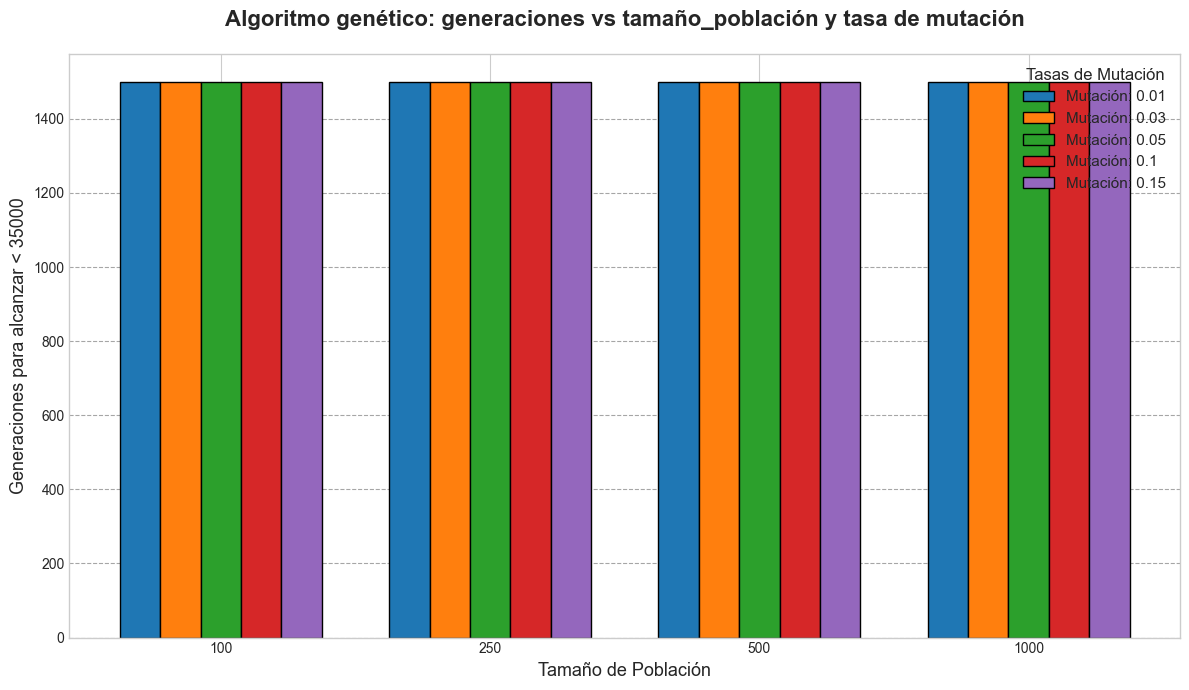

In [5]:
from GeneticAlgorithmNonStop import genetic_algorithm_2
import itertools

data = DataLoader.load_data("coordinates.txt", "solution.txt")

population_sizes = [100, 250, 500, 1000]
mutation_rates = [0.01, 0.03, 0.05, 0.1, 0.15]

tests = list(itertools.product(population_sizes, mutation_rates))
results = {pop: [] for pop in population_sizes}

for pop, mut in tests:
    print(f"Ejecutando Test -> Población: {pop} | Mutación: {mut}")
    best, history, gen = genetic_algorithm_2(data, population_size=pop, mutation_rate=mut)
    results[pop].append(gen)

plt.style.use('seaborn-v0_8-swhitegrid')
fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

x = np.arange(len(population_sizes))
width = 0.15
offsets = [-2 * width, -width, 0, width, 2 * width]
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, mut in enumerate(mutation_rates):
    generations_list = [results[pop][i] for pop in population_sizes]
    ax.bar(x + offsets[i], generations_list, width, label=f'Mutación: {mut}', color=colores[i], edgecolor='black')

ax.set_title('Algoritmo genético: generaciones vs tamaño_población y tasa de mutación', fontsize=16,
             fontweight='bold', pad=20)
ax.set_xlabel('Tamaño de Población', fontsize=13)
ax.set_ylabel('Generaciones para alcanzar < 35000', fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(population_sizes)

ax.legend(title='Tasas de Mutación', fontsize=11, title_fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

El gráfico muestra como con la versión vista en clase (con pequeñas modificaciones, pero misma esencia) tiene un resultado desastroso. Por desgracia las líneas de convergencia tardaron mucho en cargar y no se pueden ver en este trabajo, pero se ve como se atascan en mínimos locales. En general como se vio en el anterior experimento, la tasa de mutación penaliza mucho al algoritmo y una demasiado baja hace que descienda muy lentamente. Por tanto, este gráfico sirve para concluir que no tiene buenos resultados el algoritmo visto en clase con relativas pocas iteraciones (1500).

## Tercera versión
Aquí se han implementado dos versiones. Después de investigar los posibles problemas que puedan producir la no convergencia, llegué a dos conclusiones. La primera es que había nudos. Es como clavos y un ovillo de lana cuando se intenta hacer un perímetro, pero se van cruzando. La mejor solución es darle la vuelta a aquel trozo que no encaja y puede haber un nudo, así se puede solucionar ese problema.

Por otro lado, también me di cuenta de que se puede mejorar el cruce añadiendo heurística o una versión primitiva de la programación dinámica. Aprovechando mis conocimientos de Fundamentos de los Sistemas Inteligentes se me ocurrió que se puede mejorar el cruce con _intuición_. Se empieza como la madre, entonces se va preguntando a los padres si han encontrado una ciudad más cercana que la que vendría la siguiente. Es decir, que va cogiendo el conocimiento aprendido de los padres para ver si es posible que haya un camino más corto entre ciudades. En caso de estar perdido se coge una ciudad aleatoria. De este modo se espera que los hijos vayan aprendiendo los mejores tramos entre ciudades de los padres y por azar y un poco de ayuda se pueda llegar a una mejor solución.

Ambas soluciones también aportan variación genética para no llegar a la endogamia. Aunque todo esto tenía mucho sentido, tardaba muchas generaciones en alcanzar una solución óptima. Y después de varios experimentos, inferí que se puede deber a que hay endogamia prematura porque al final todos los hijos acaban pareciendose a los padres y tienen sus mismos nudos. Para solucionarlo se implementó una nueva mecánica. Esta consiste en añadir un 20% de individuos aleatorios a la mezcla y por azar uno de ellos tenga la solución a ese último nudo, y por ello se solucione el problema antes.

### Problemas en la implemetacion de los nuevos métodos
Con la experimentación de diversos parámetros y depuración se encontraron diversos problemas.

- El elitismo: Al coger al mejor padre como único sucesor y "mejor" individuo se perdía mucha genética valiosa por el camino. Después de muchas pruebas, mejoró hasta en 6 veces la velocidad del algoritmo con un par de cambios. El primero fue simplificar la función que devolvía los mejores padres. Había un bucle while que en parte impedía que se pudieran repetir y eso estaba un poco cogido con pinzas. Por otra parte, y creo que la más importante, fue guardar 5 "mejores" individuos por generación. Pero no se podía guardar de cualquier manera, por ello se seleccionaron 5 con distintas distancias. Era muy probable que si tenían distancias diferentes iban a tener nudos diferentes. Así se consiguió que pudieran aprender entre ellos, sin clonar generaciones enteras.

- El factor del azar: muchos experimentos podían converger en apenas 50 generaciones porque tuvieron una excelente primera generación. El factor suerte afecta desde 4 frentes distintos. El primero es en la función de cruce, donde si los padres no conocen el camino, escoge uno de manera aleatoria. Otro sería la cantidad de extranjeros que se unen a la generación. Es en esa chispa de novedad donde o bien te encuentras con una solución óptima o bien se sigue estancando la curva. Para continuar, se puede observar el torneo de selección de padres. Se introduce por mutación y por una nueva generación "espontánea" una gran cantidad de posible soluciones a los problemas. Pero, cabe destacar, que no tienen por qué brillar en la distancia, destacan por la solución de un nudo en específico. Es por ello, que el torneo, pese a ser justo, no es equitativo y suele dar ventaja a aquellos padres que ya han aprendido anteriormente. Por último está el factor de la mutación. He experimentado con varias versiones de la mutación con cruce y un solo cruce no suele ser suficiente para resolver el problema. Es por ello que se modificó para que se hicieran 3 cruces siempre y cuando estuviera el objetivo lejos y uno solo para cuando se acerca a una solución. De este modo se puede controlar la precisión con la que actúa, sin tener que romper todo el trabajo anterior.

El último punto es el más importante a tener en consideración. Véase que se tuvieron que corregir muchos aspectos del código para aprovechar la ventaja del azar y mejorar un algoritmo que sea puramente aleatorio. Con un aprendizaje constante, una simulación más realista de lo que es adaptarse o morir y un poco de paciencia y experimentación he llegado a una implementación mejor. Se puede ver en la siguiente gráfica, que adapta los resultados a la ponderación de 5 experimentos usando los mismos parámetros.

Ejecutando Test Heurístico -> Población: 100 | Mutación: 0.05
Generation 0 129617.1683794388
Generation 100 42570.58588373394
Generation 200 42570.58588373394
Generation 300 42412.64500755943
Generation 400 40821.58785902612
Generation 500 40821.58785902612
Generation 600 40356.82091282481
Generation 700 40353.76722525303
Generation 800 40353.76722525303
Generation 900 40353.76722525303
Generation 1000 40353.76722525303
Generation 1100 40353.76722525303
Generation 1200 40353.76722525303
Generation 1300 40352.86631784212
Generation 1400 39647.97234833683
Generation 0 123868.41273380686
Generation 100 51280.213127918876
Generation 200 49463.09791976999
Generation 300 48086.597591100726
Generation 400 46192.01796070179
Generation 500 46192.01796070179
Generation 600 46192.01796070179
Generation 700 45644.25042321859
Generation 800 44820.004465855134
Generation 900 43407.204163444716
Generation 1000 43308.04047062586
Generation 1100 43308.04047062586
Generation 1200 42079.07963677665
Gener

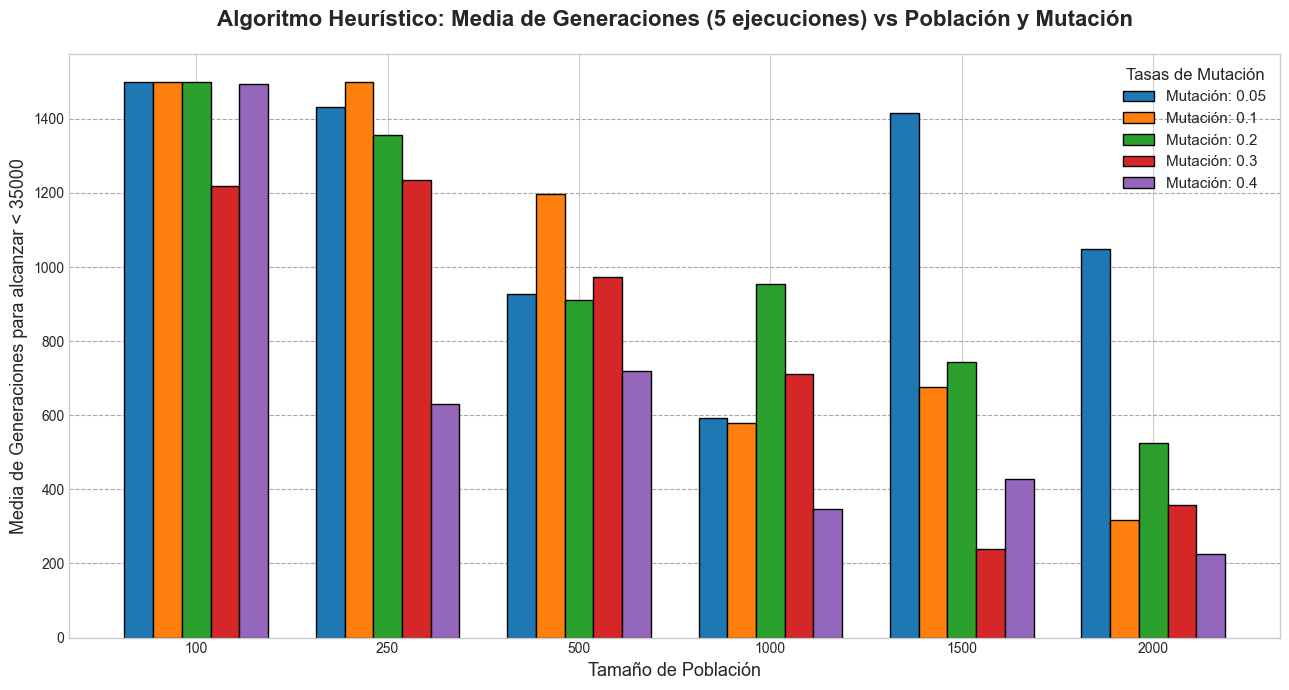

In [2]:
from HeuristicGeneticAlgorithm import heuristic_genetic_algorithm
import itertools

data = DataLoader.load_data("coordinates.txt", "solution.txt")

population_sizes = [100, 250, 500, 1000, 1500, 2000]
mutation_rates = [0.05, 0.1, 0.2, 0.3, 0.4]
repetitions = 5

tests = list(itertools.product(population_sizes, mutation_rates))
results = {pop: [] for pop in population_sizes}

for pop, mut in tests:
    print(f"Ejecutando Test Heurístico -> Población: {pop} | Mutación: {mut}")
    gen_sum = 0
    for _ in range(repetitions):
        best, history, gen = heuristic_genetic_algorithm(data, population_size=pop, mutation_rate=mut)
        gen_sum += gen

    avg_gen = gen_sum / repetitions
    results[pop].append(avg_gen)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(13, 7), dpi=100)

x = np.arange(len(population_sizes))
width = 0.15
offsets = [-2 * width, -width, 0, width, 2 * width]
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, mut in enumerate(mutation_rates):
    generations_list = [results[pop][i] for pop in population_sizes]
    ax.bar(x + offsets[i], generations_list, width, label=f'Mutación: {mut}', color=colores[i], edgecolor='black')

ax.set_title('Algoritmo Heurístico: Media de Generaciones (5 ejecuciones) vs Población y Mutación', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Tamaño de Población', fontsize=13)
ax.set_ylabel('Media de Generaciones para alcanzar < 35000', fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(population_sizes)

ax.legend(title='Tasas de Mutación', fontsize=11, title_fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("grafica_heuristica_promedio.png", bbox_inches='tight', dpi=300)
plt.show()

Se puede concluir que cuando las poblaciones son pequeñas, se forma un comportamiento caótico debido a que no se puede controlar la aleatoriedad con pocos padres y guardado de las rutas buenas. Conforme va avanzando a partir de 500 individuos en la generación ya se ve cómo el algoritmo empieza a brillar. Con más individuos en la población acaba por encontrar solución más pronto. También cabe destacar que cada número de individuos tiene un mutation rate óptimo diferente. Puesto que con 1000 se comporta más como una normal con media en 0.2, mientras que parece que con 2000 cuanto mayor sea la tasa de mutación parece ir más rápido. En general es encontrar un equilibrio entre más parámetros, aunque en este experimento se han asilado los dos que se pedían en el enunciado.

## Conclusiones